# King County Housing Market Analysis
## Helping Nicole Johnson identify the best value homes in central King County neighborhoods within a moderate budget

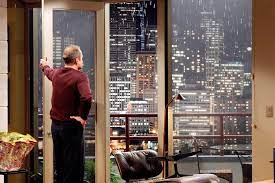

# Business Problem

The Nicole Johnson is a potential home buyer interested in purchasing property in King County.

The goal of this analysis is to identify the factors that influence house prices and provide data-driven recommendations regarding:
- location
- property characteristics
- pricing trends
- investment value

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)
import seaborn as sns
plt.style.use('bmh')

In [2]:
# Load Dataset
df = pd.read_csv("data/joined_table_revised.csv")

### Initial Data Exploration

In [3]:
# Shape
df.shape

(21597, 21)

In [4]:
# Columns
df.columns

Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'date', 'price'],
      dtype='str')

In [5]:
# First Rows
df.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3.000,1.000,1180.000,5650.000,1.000,NaN,0.000,3,7,...,0.000,1955,0.000,98178,47.511,-122.257,1340.000,5650.000,2014-10-13,221900.000
1,6414100192,3.000,2.250,2570.000,7242.000,2.000,0.000,0.000,3,7,...,400.000,1951,19910.000,98125,47.721,-122.319,1690.000,7639.000,2014-12-09,538000.000
2,5631500400,2.000,1.000,770.000,10000.000,1.000,0.000,0.000,3,6,...,0.000,1933,NaN,98028,47.738,-122.233,2720.000,8062.000,2015-02-25,180000.000
3,2487200875,4.000,3.000,1960.000,5000.000,1.000,0.000,0.000,5,7,...,910.000,1965,0.000,98136,47.521,-122.393,1360.000,5000.000,2014-12-09,604000.000
4,1954400510,3.000,2.000,1680.000,8080.000,1.000,0.000,0.000,3,8,...,0.000,1987,0.000,98074,47.617,-122.045,1800.000,7503.000,2015-02-18,510000.000


In [6]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   bedrooms       21597 non-null  float64
 2   bathrooms      21597 non-null  float64
 3   sqft_living    21597 non-null  float64
 4   sqft_lot       21597 non-null  float64
 5   floors         21597 non-null  float64
 6   waterfront     19206 non-null  float64
 7   view           21534 non-null  float64
 8   condition      21597 non-null  int64  
 9   grade          21597 non-null  int64  
 10  sqft_above     21597 non-null  float64
 11  sqft_basement  21145 non-null  float64
 12  yr_built       21597 non-null  int64  
 13  yr_renovated   17749 non-null  float64
 14  zipcode        21597 non-null  int64  
 15  lat            21597 non-null  float64
 16  long           21597 non-null  float64
 17  sqft_living15  21597 non-null  float64
 18  sqft_lot15     21

In [7]:
# Statistical Summary
df.describe()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price
count,21597.000,21597.000,21597.000,21597.000,21597.000,21597.000,19206.000,21534.000,21597.000,21597.000,21597.000,21145.000,21597.000,17749.000,21597.000,21597.000,21597.000,21597.000,21597.000,21597.000
mean,4580474287.771,3.373,2.116,2080.322,15099.409,1.494,0.008,0.234,3.410,7.658,1788.597,291.857,1971.000,836.651,98077.952,47.560,-122.214,1986.620,12758.284,540296.574
std,2876735715.748,0.926,0.769,918.106,41412.637,0.540,0.087,0.766,0.651,1.173,827.760,442.491,29.375,4000.111,53.513,0.139,0.141,685.230,27274.442,367368.140
min,1000102.000,1.000,0.500,370.000,520.000,1.000,0.000,0.000,1.000,3.000,370.000,0.000,1900.000,0.000,98001.000,47.156,-122.519,399.000,651.000,78000.000
25%,2123049175.000,3.000,1.750,1430.000,5040.000,1.000,0.000,0.000,3.000,7.000,1190.000,0.000,1951.000,0.000,98033.000,47.471,-122.328,1490.000,5100.000,322000.000
50%,3904930410.000,3.000,2.250,1910.000,7618.000,1.500,0.000,0.000,3.000,7.000,1560.000,0.000,1975.000,0.000,98065.000,47.572,-122.231,1840.000,7620.000,450000.000
75%,7308900490.000,4.000,2.500,2550.000,10685.000,2.000,0.000,0.000,4.000,8.000,2210.000,560.000,1997.000,0.000,98118.000,47.678,-122.125,2360.000,10083.000,645000.000
max,9900000190.000,33.000,8.000,13540.000,1651359.000,3.500,1.000,4.000,5.000,13.000,9410.000,4820.000,2015.000,20150.000,98199.000,47.778,-121.315,6210.000,871200.000,7700000.000


### Data cleanup

In [8]:
# remove duplicates
df.duplicated().sum()
df = df.drop_duplicates()

In [9]:
# convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

In [10]:
# Missing Values
missing = df.isna().sum()

missing[missing > 0]

waterfront       2391
view               63
sqft_basement     452
yr_renovated     3848
dtype: int64

## Missing Values Observation

The dataset contains missing values in:
- waterfront
- yr_renovated
- view
- sqft_basement

These missing values will be handled depending on their business meaning.

In [11]:
# Replace missing values with 0 where the absence of a feature is a meaningful interpretation

df["waterfront"] = df["waterfront"].fillna(0)
df["sqft_basement"] = df["sqft_basement"].fillna(0)
df["yr_renovated"] = df["yr_renovated"].fillna(0)
df["view"] = df["view"].fillna(0)
# Convert renovation years from values ending with an extra zero (e.g., 20150 → 2015)
# and change the data type from float to integer
df["yr_renovated"] = (df["yr_renovated"] /10).astype(int) # Please only run this cell once to avoid converting the values multiple times.


## Missing Values Treatment

The dataset contained missing values in four variables: `waterfront`, `view`, `sqft_basement`, and `yr_renovated`.

Rather than removing observations, the missing values were handled using domain-specific assumptions to preserve the dataset and maintain business meaning.

### Handling Decisions

- **waterfront**: Missing values were replaced with `0`, assuming that properties with missing information do not have waterfront access.
- **view**: Missing values were replaced with `0`, assuming no special view rating was recorded.
- **sqft_basement**: Missing values were replaced with `0`, indicating that the property does not have a basement.
- **yr_renovated**: Missing values were replaced with `0`, indicating that the property has never been renovated.

### Justification

These assumptions are supported by the distributions of the variables, where `0` was already the most common value. Therefore, imputing missing values with `0` preserves observations while maintaining a realistic interpretation of the housing characteristics.

After the imputation process, the dataset contained no remaining missing values and was ready for further exploratory data analysis.

# Research Questions & Hypotheses

## Question 1
### Does house size affect house price?
### Hypothesis
The larger the living area, the higher the house price.

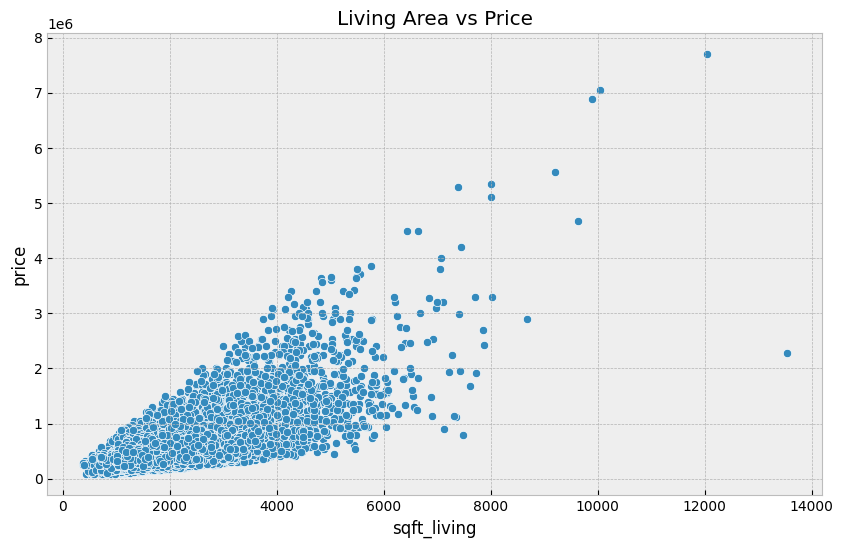

In [12]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="sqft_living",
    y="price",
    data=df
)

plt.title("Living Area vs Price")

plt.show()

## Research Question 2
Does buying timing influence average house prices?

### Hypothesis
Average house prices fluctuate across different months of the year.


# Time-Based Analysis

Since Nicole Johnson plans to buy within the next year, analyzing seasonal price trends may help identify better purchasing periods.


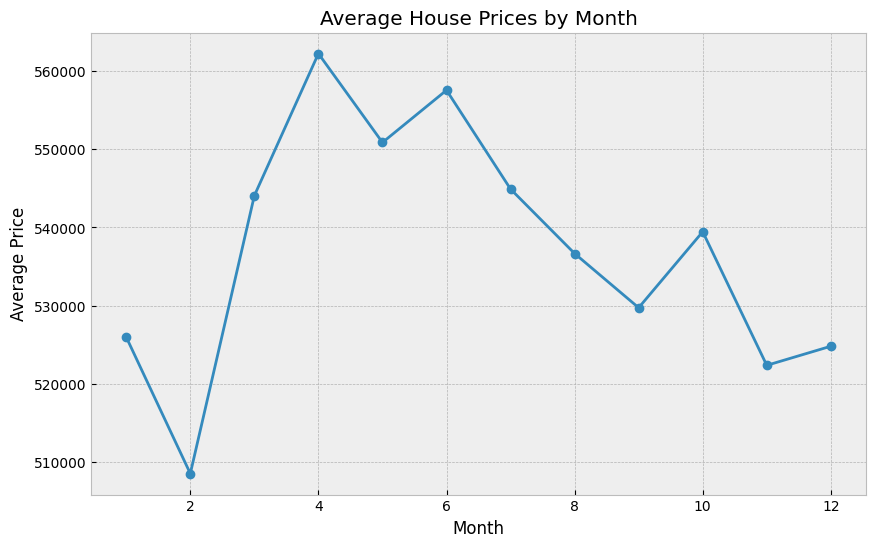

In [13]:

# Convert date column
df_sqlalchemy_joined =df
df_sqlalchemy_joined["date"] = pd.to_datetime(df["date"])

# Create month feature
df_sqlalchemy_joined["month"] = df_sqlalchemy_joined["date"].dt.month

# Average monthly prices
monthly_prices = (
    df_sqlalchemy_joined
    .groupby("month")["price"]
    .mean()
)

# Plot
monthly_prices.plot(
    kind="line",
    figsize=(10,6),
    marker="o",
    title="Average House Prices by Month"
)

plt.xlabel("Month")
plt.ylabel("Average Price")

plt.show()


### Monthly House Price Analysis

The average house price varies throughout the year, with prices generally increasing from February and peaking in April. After mid-year, average prices show a gradual decline, reaching lower levels toward the end of the year. Overall, the variation across months is relatively small, suggesting that seasonality has only a modest impact on house prices in this dataset.

## Question 3
### Does location influence housing prices?
### Hypothesis
Houses in certain zipcodes have significantly higher average prices


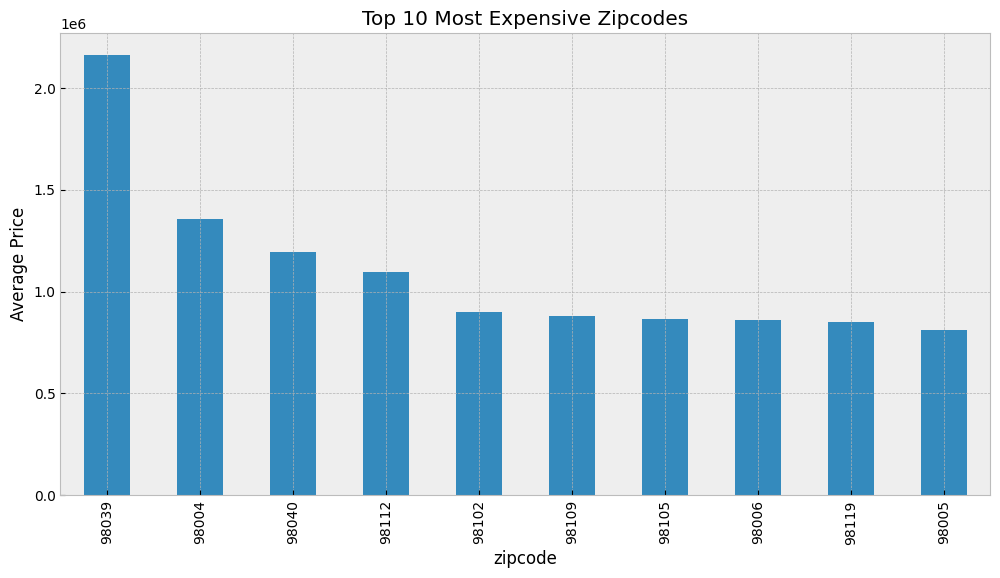

In [14]:
# Average Price by Zipcode
zipcode_price = (
    df.groupby("zipcode")["price"]
    .mean()
    .sort_values(ascending=False)
)

#zipcode_price.head(10)
plt.figure(figsize=(12,6))

zipcode_price.head(10).plot(kind="bar")

plt.title("Top 10 Most Expensive Zipcodes")

plt.ylabel("Average Price")

plt.show()

### Housing prices vary significantly across zipcodes, indicating strong geographical clustering of property values.

Insight 1

Houses with larger living areas (sqft_living) generally have higher prices, showing one of the strongest positive correlations in the dataset.

Insight 2

Average house prices fluctuate moderately throughout the year, peaking around April and remaining relatively stable overall, indicating a weak seasonal effect on housing prices.

Insight 3 (Geographical)

Certain zipcodes consistently show much higher average prices, suggesting strong geographical price clustering in King County.



Recommendation 1

Focus on neighborhoods with moderate average prices but growing property values rather than premium zipcodes with already inflated prices.

Recommendation 2

Seasonal effects appear relatively weak, suggesting that property characteristics and location are more important drivers of value than the month of sale.

Recommendation 3

Consider older renovated homes because they may provide better value than newly built luxury properties.

# Additional Analysis

### Univariate Analysis

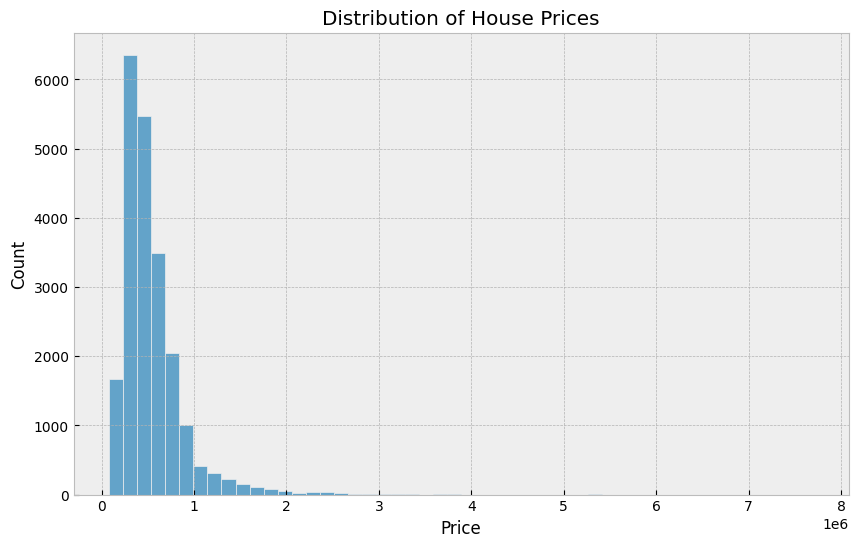

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(df["price"], bins=50)

plt.title("Distribution of House Prices")

plt.xlabel("Price")

plt.ylabel("Count")

plt.show()

### Original Price Distribution
The house prices are highly right-skewed, with most houses concentrated at lower price ranges and a small number of very expensive houses creating a long right tail. This indicates the presence of outliers and a non-normal distribution.

<Axes: xlabel='log_price', ylabel='Count'>

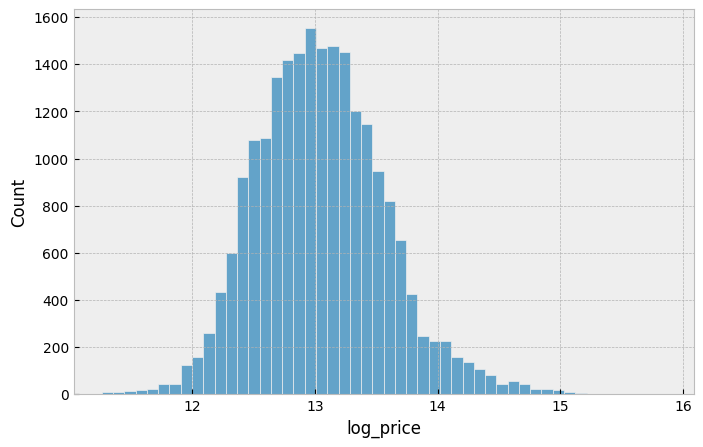

In [16]:
df["log_price"] = np.log(df["price"])
sns.histplot(df["log_price"], bins=50)

### Log-Transformed Price Distribution
After applying a logarithmic transformation, the distribution becomes much more symmetric and approximately normal. The extreme high-price values are compressed, reducing skewness and making the overall pattern easier to analyze.

### Why Use Log Transformation?
Log transformation is used because the original price distribution is heavily skewed. It reduces the influence of extreme values, improves visualization of the data, and helps satisfy the normality assumptions required by many statistical and machine learning models.

### Correlation Analysis

In [17]:
# Select only numerical columns for correlation analysis
df_num = df.select_dtypes(include=['float64', 'int64'])

# Calculate correlation of all numerical features with the target variable (price)
# Exclude the price and log_price columns because they represent the correlation of these variables with themselves (1.0)
df_num_corr = df_num_corr = df_num.corr()['price'].drop(['price','log_price'])

# Filter features with absolute correlation greater than 0.3
# and sort them from highest to lowest correlation
golden_features_list = df_num_corr[abs(df_num_corr) > 0.3].sort_values(ascending=False)

# Display the selected features and their correlation coefficients
print("There is {} strongly correlated values with SalePrice:\n{}".format(
    len(golden_features_list),
    golden_features_list
))

There is 9 strongly correlated values with SalePrice:
sqft_living     0.702
grade           0.668
sqft_above      0.605
sqft_living15   0.585
bathrooms       0.526
view            0.393
sqft_basement   0.321
bedrooms        0.309
lat             0.307
Name: price, dtype: float64


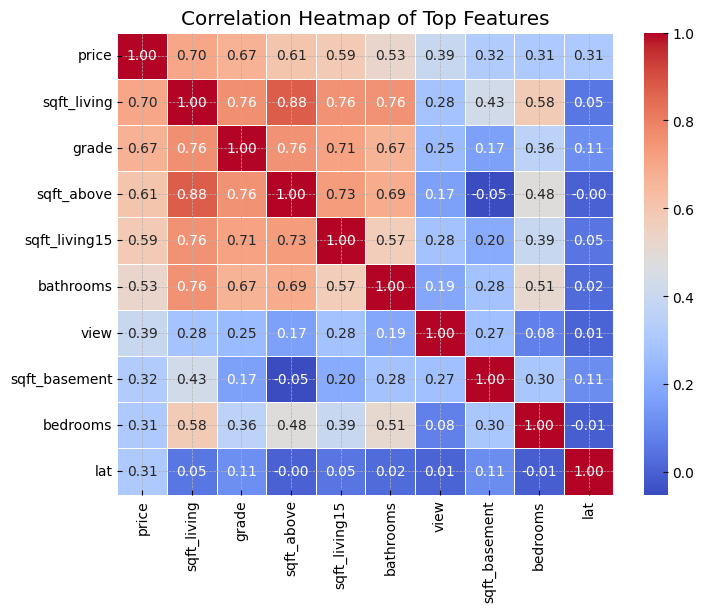

In [18]:
# Select the most relevant features for further correlation analysis
top_features = [
    'price',
    'sqft_living',
    'grade',
    'sqft_above',
    'sqft_living15',
    'bathrooms',
    'view',
    'sqft_basement',
    'bedrooms',
    'lat'
]

# Compute the correlation matrix among the selected features
corr_matrix = df[top_features].corr()

# Plot a heatmap to visualize correlations between features
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Top Features')
plt.show()

### Correlation Analysis of Key Features
The correlation analysis identified nine features with a moderate to strong positive relationship with house price (r > 0.30). Among them, `sqft_living` (0.70) and grade (0.67) exhibit the strongest correlations, indicating that larger homes and higher construction quality are associated with higher prices.

The heatmap also reveals strong correlations among several predictor variables. In particular, `sqft_living` and `sqft_above` have a very high correlation (0.88), suggesting potential multicollinearity since both variables measure similar aspects of house size. Additionally, `sqft_living`, `grade`, `sqft_living15`, and bathrooms are strongly correlated with one another.

Features such as `view`, `sqft_basement`, bedrooms, and lat show moderate correlations with price while maintaining relatively lower correlations with other predictors. These variables may provide additional information beyond house size and quality.

#### Key Findings
`sqft_living` is the strongest predictor of house price (r = 0.70).
`grade` is the second most influential feature (r = 0.67).
`sqft_living` and `sqft_above` are highly correlated (r = 0.88), indicating possible redundancy.
`view` and `lat` have moderate correlations with price but low correlations with most other features, suggesting they may contribute unique information.
Several size-related features are strongly correlated with each other, which should be considered during model development to avoid multicollinearity issues.

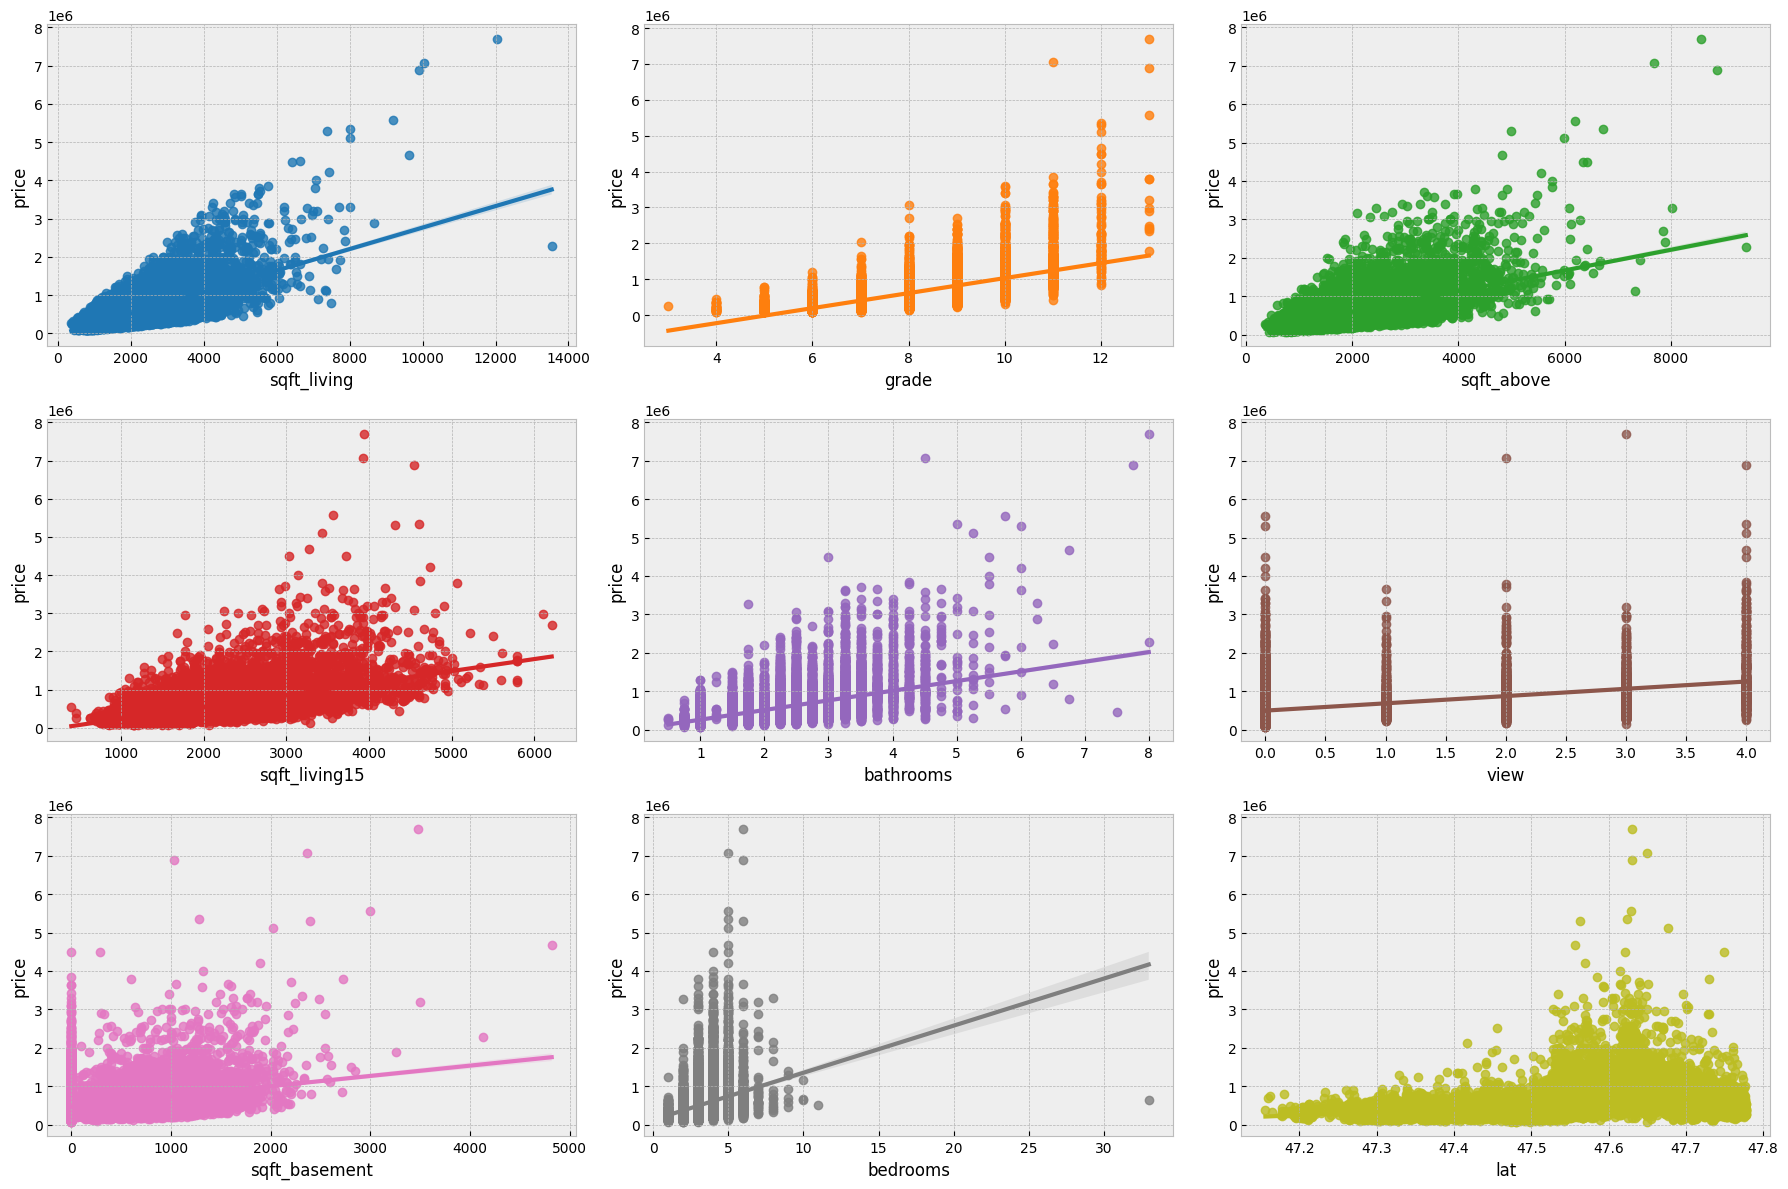

In [19]:
features = [col for col in top_features if col != 'price']
colors = sns.color_palette("tab10", len(features))

fig, ax = plt.subplots(round(len(features) / 3), 3, figsize=(18, 12))

for i, ax in enumerate(fig.axes):
    if i < len(features):
        sns.regplot(
            x=features[i],
            y='price',
            data=df,
            ax=ax,
            color=colors[i]
        )

plt.tight_layout()
plt.show()


### Regression Plot Analysis
The regression plots confirm that most selected features have a positive relationship with house price. Among all variables, `sqft_livin` and `grade` show the strongest associations with price. Size-related features such as `sqft_above`, `sqft_living15`, and `bathrooms` also display clear positive trends. Features like `view`, `sqft_basement`, `bedrooms`, and `lat` have weaker but still positive relationships with price. Overall, larger, higher-quality, and better-located houses tend to have higher market values.

# Conclusion

The analysis showed that location, living space, waterfront access, and renovation status are key factors influencing housing prices in King County.

These findings can help buyers make more informed purchasing decisions.